## Creating Python Environment

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Feature Extraction

Raw audio signals cannot be directly used for training deep learning models. Therefore, we extract meaningful **acoustic features** that capture speech characteristics.

Features used in this project may include:

- **MFCC (Mel Frequency Cepstral Coefficients)** – captures speech timbre
- **Mel Spectrogram** – frequency distribution over time
- **Chroma Features** – tonal information
- **Spectral Contrast** – difference between peaks and valleys in spectrum
- **Zero Crossing Rate** – signal frequency changes

These features are converted into **sequential representations** suitable for LSTM networks.

---

## Libraries Used

The following Python libraries are used in this notebook:

- **Librosa** – audio processing and feature extraction
- **NumPy** – numerical computations
- **Pandas** – data manipulation
- **Matplotlib / Seaborn** – visualization
- **PyTorch** – deep learning model implementation
- **Scikit-learn** – evaluation metrics

---

## Expected Outcome

By the end of this notebook, we will build a **deep learning-based Speech Emotion Recognition system using LSTM networks in PyTorch** that can classify emotions from speech recordings.

This project demonstrates the integration of **audio signal processing, feature engineering, and deep learning** to understand emotional patterns in human speech.

## Import Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

## Loading the Dataset

In [3]:
dataset_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"

paths = []
emotions = []

emotion_dict = {
    '01':'neutral',
    '02':'calm',
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            emotion = emotion_dict[file.split("-")[2]]
            path = os.path.join(root, file)

            paths.append(path)
            emotions.append(emotion)

df = pd.DataFrame()
df["path"] = paths
df["emotion"] = emotions

df.head()

,path,emotion
0,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,surprised
1,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,neutral
2,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,disgust
3,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,disgust
4,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,neutral


## Emotion Distribution

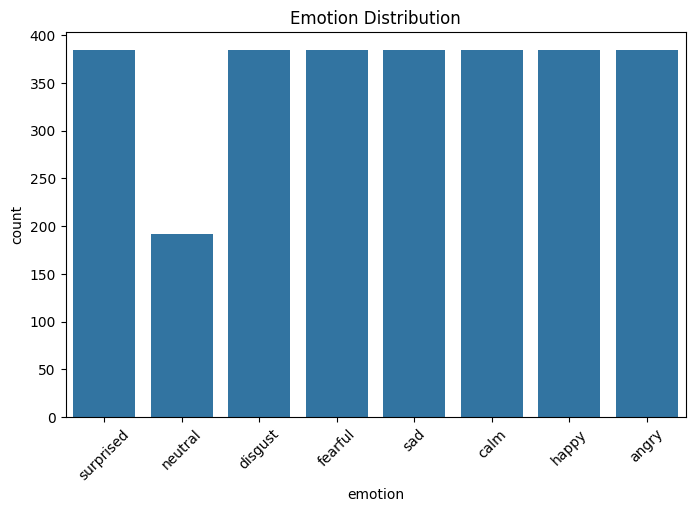

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

## Audio Signal Visualization

**Waveform**

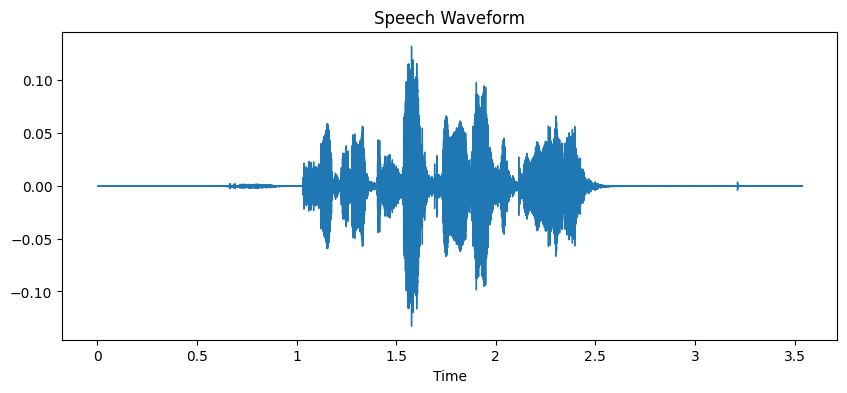

In [5]:
sample_path = df.path.iloc[0]
signal, sr = librosa.load(sample_path)

plt.figure(figsize=(10,4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Speech Waveform")
plt.show()

**Spectrogram**

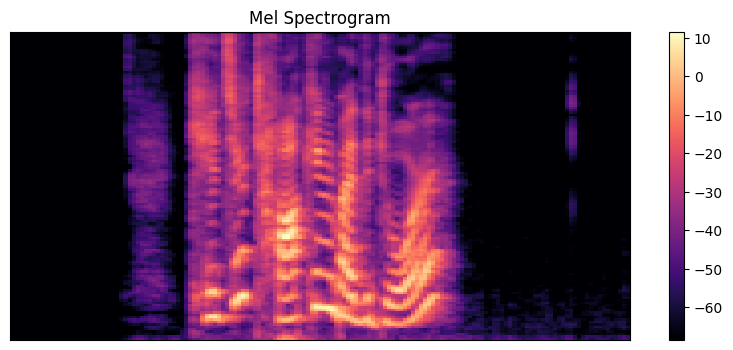

In [6]:
spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.power_to_db(spectrogram))
plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

In [7]:
def extract_features(file_path):
    
    signal, sr = librosa.load(file_path, duration=3, offset=0.5)
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    
    return np.mean(mfcc.T, axis=0)

## Preparing Training Data

In [8]:
X = []
y = []

for path, emotion in zip(df.path, df.emotion):
    
    features = extract_features(path)
    
    X.append(features)
    y.append(emotion)

X = np.array(X)
y = np.array(y)

## Encoding Emotion Labels

In [9]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

## Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Convert Data to PyTorch Tensors

In [11]:
X_train = torch.tensor(X_train).float()
X_test = torch.tensor(X_test).float()

y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

## LSTM Model Architecture

In [12]:
class EmotionLSTM(nn.Module):
    
    def __init__(self, input_size, hidden_size, num_classes):
        
        super(EmotionLSTM, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        
        x = x.unsqueeze(1)
        
        output, (hn, cn) = self.lstm(x)
        
        out = self.fc(hn[-1])
        
        return out

## Model Initialization

In [13]:
input_size = X_train.shape[1]
hidden_size = 128
num_classes = len(np.unique(y))

model = EmotionLSTM(input_size, hidden_size, num_classes)

## Training Configuration

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Baseline Model Training

In [15]:
epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 30
counter = 0

for epoch in range(epochs):

    # ======================
    # TRAINING
    # ======================
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Training accuracy
    _, predicted = torch.max(outputs, 1)
    train_acc = (predicted == y_train).sum().item() / y_train.size(0)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    with torch.no_grad():

        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)

        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = (val_predicted == y_test).sum().item() / y_test.size(0)

    # ======================
    # STORE VALUES
    # ======================
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ======================
    # EARLY STOPPING
    # ======================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_lstm_ser_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

    # ======================
    # PRINT PROGRESS
    # ======================
    if (epoch+1) % 10 == 0 or epoch == 0:

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")
        print("--------------------------------------------------")

Epoch [1/100]
Train Loss: 2.1073 | Train Acc: 0.0534
Val   Loss: 2.1072 | Val   Acc: 0.0747
--------------------------------------------------
Epoch [10/100]
Train Loss: 2.0399 | Train Acc: 0.1806
Val   Loss: 2.0464 | Val   Acc: 0.2031
--------------------------------------------------
Epoch [20/100]
Train Loss: 1.9816 | Train Acc: 0.2886
Val   Loss: 1.9840 | Val   Acc: 0.2865
--------------------------------------------------
Epoch [30/100]
Train Loss: 1.9193 | Train Acc: 0.2977
Val   Loss: 1.9254 | Val   Acc: 0.3056
--------------------------------------------------
Epoch [40/100]
Train Loss: 1.8584 | Train Acc: 0.3329
Val   Loss: 1.8703 | Val   Acc: 0.3472
--------------------------------------------------
Epoch [50/100]
Train Loss: 1.7936 | Train Acc: 0.3429
Val   Loss: 1.8162 | Val   Acc: 0.3490
--------------------------------------------------
Epoch [60/100]
Train Loss: 1.7313 | Train Acc: 0.3746
Val   Loss: 1.7535 | Val   Acc: 0.3733
--------------------------------------------

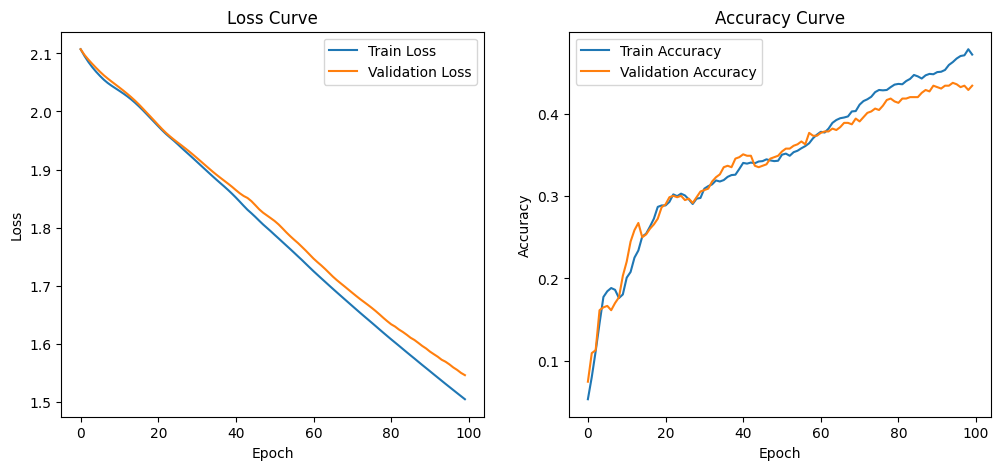

In [16]:
plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Model Evaluation

In [17]:
with torch.no_grad():
    
    predictions = model(X_test)
    
    predicted = torch.argmax(predictions, axis=1)

## Classification Report

## Confusion Matrix

In [18]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.63      0.61      0.62        87
           1       0.44      0.69      0.54        84
           2       0.39      0.36      0.38        75
           3       0.42      0.44      0.43        62
           4       0.38      0.33      0.36        69
           5       0.00      0.00      0.00        35
           6       0.27      0.18      0.22        89
           7       0.43      0.61      0.50        75

    accuracy                           0.43       576
   macro avg       0.37      0.40      0.38       576
weighted avg       0.40      0.43      0.41       576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


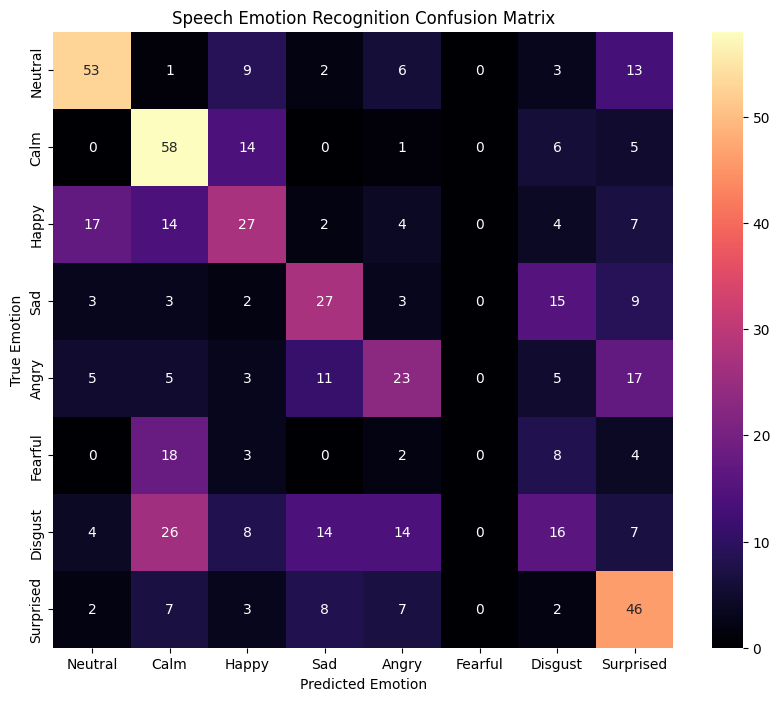

In [19]:
# Create confusion matrix
cm = confusion_matrix(y_test, predicted)

labels = ['Neutral','Calm','Happy','Sad','Angry','Fearful','Disgust','Surprised']

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='magma')

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Speech Emotion Recognition Confusion Matrix")

plt.show()

# Advanced Approaches

## BiLSTM

In [20]:
class EmotionBiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(EmotionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        output, (hn, cn) = self.lstm(x)

        out = self.fc(output[:, -1, :])

        return out

In [21]:
input_size = X_train.shape[1]
hidden_size = 128
num_classes = len(np.unique(y))

model_bilstm = EmotionBiLSTM(input_size, hidden_size, num_classes)

## CNN + BiLSTM

In [22]:
class CNN_BiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(CNN_BiLSTM, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.permute(0,2,1)

        output, _ = self.lstm(x)

        out = self.fc(output[:, -1, :])

        return out

In [23]:
model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)

In [24]:
def train_model(model, model_name, X_train, y_train, X_test, y_test,
                criterion, optimizer, epochs=100, patience=30):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):

        # ======================
        # TRAINING
        # ======================
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Training accuracy
        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train).sum().item() / y_train.size(0)

        # ======================
        # VALIDATION
        # ======================
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test)

            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = (val_predicted == y_test).sum().item() / y_test.size(0)

        # ======================
        # STORE VALUES
        # ======================
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ======================
        # EARLY STOPPING
        # ======================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            counter = 0

            torch.save(model.state_dict(), f"best_{model_name}.pth")

        else:
            counter += 1

        if counter >= patience:

            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # ======================
        # PRINT PROGRESS
        # ======================
        if (epoch+1) % 10 == 0 or epoch == 0:

            print(f"{model_name} Epoch [{epoch+1}/{epochs}]")

            print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")

            print("--------------------------------------------------")

    return train_losses, val_losses, train_accuracies, val_accuracies

## Train BiLSTM Model

In [25]:
model_bilstm = EmotionBiLSTM(input_size, 128, num_classes)

optimizer_bilstm = torch.optim.Adam(model_bilstm.parameters(), lr=0.001)

train_losses_bi, val_losses_bi, train_acc_bi, val_acc_bi = train_model(
    model_bilstm,
    "bilstm",
    X_train, y_train,
    X_test, y_test,
    criterion,
    optimizer_bilstm
)

bilstm Epoch [1/100]
Train Loss: 2.0792 | Train Acc: 0.1376
Val   Loss: 2.0657 | Val   Acc: 0.1406
--------------------------------------------------
bilstm Epoch [10/100]
Train Loss: 2.0188 | Train Acc: 0.2569
Val   Loss: 2.0104 | Val   Acc: 0.2465
--------------------------------------------------
bilstm Epoch [20/100]
Train Loss: 1.8889 | Train Acc: 0.3121
Val   Loss: 1.8782 | Val   Acc: 0.3229
--------------------------------------------------
bilstm Epoch [30/100]
Train Loss: 1.7308 | Train Acc: 0.3611
Val   Loss: 1.7402 | Val   Acc: 0.3663
--------------------------------------------------
bilstm Epoch [40/100]
Train Loss: 1.5800 | Train Acc: 0.4180
Val   Loss: 1.6144 | Val   Acc: 0.4080
--------------------------------------------------
bilstm Epoch [50/100]
Train Loss: 1.4188 | Train Acc: 0.4896
Val   Loss: 1.4671 | Val   Acc: 0.4635
--------------------------------------------------
bilstm Epoch [60/100]
Train Loss: 1.2549 | Train Acc: 0.5451
Val   Loss: 1.3179 | Val   Acc: 0.

## Train CNN + BiLSTM Model

In [26]:
model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)

optimizer_cnn = torch.optim.Adam(model_cnnbilstm.parameters(), lr=0.001)

train_losses_cnn, val_losses_cnn, train_acc_cnn, val_acc_cnn = train_model(
    model_cnnbilstm,
    "cnnbilstm",
    X_train, y_train,
    X_test, y_test,
    criterion,
    optimizer_cnn
)

cnnbilstm Epoch [1/100]
Train Loss: 2.0781 | Train Acc: 0.1215
Val   Loss: 2.0661 | Val   Acc: 0.1510
--------------------------------------------------
cnnbilstm Epoch [10/100]
Train Loss: 1.9866 | Train Acc: 0.2352
Val   Loss: 1.9644 | Val   Acc: 0.2483
--------------------------------------------------
cnnbilstm Epoch [20/100]
Train Loss: 1.8096 | Train Acc: 0.3112
Val   Loss: 1.8034 | Val   Acc: 0.3003
--------------------------------------------------
cnnbilstm Epoch [30/100]
Train Loss: 1.6962 | Train Acc: 0.3338
Val   Loss: 1.6994 | Val   Acc: 0.3333
--------------------------------------------------
cnnbilstm Epoch [40/100]
Train Loss: 1.5880 | Train Acc: 0.3859
Val   Loss: 1.5910 | Val   Acc: 0.3733
--------------------------------------------------
cnnbilstm Epoch [50/100]
Train Loss: 1.4235 | Train Acc: 0.4605
Val   Loss: 1.4876 | Val   Acc: 0.4323
--------------------------------------------------
cnnbilstm Epoch [60/100]
Train Loss: 1.3391 | Train Acc: 0.4948
Val   Loss: 1

## Plot Accuracy Comparison

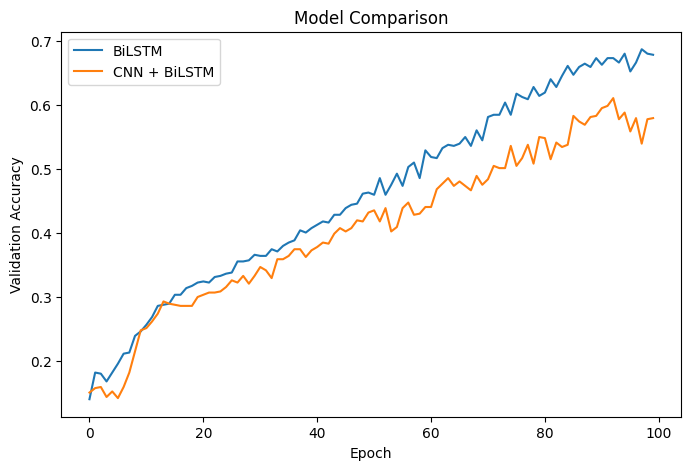

In [27]:
plt.figure(figsize=(8,5))

plt.plot(val_acc_bi, label="BiLSTM")
plt.plot(val_acc_cnn, label="CNN + BiLSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")

plt.legend()

plt.show()

## Plot Loss Comparison

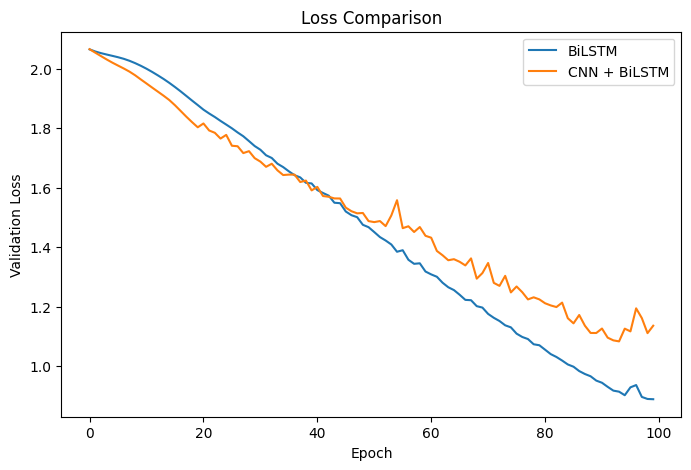

In [28]:
plt.figure(figsize=(8,5))

plt.plot(val_losses_bi, label="BiLSTM")
plt.plot(val_losses_cnn, label="CNN + BiLSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison")

plt.legend()

plt.show()

In [29]:
# BiLSTM Predictions
model_bilstm.eval()

with torch.no_grad():
    outputs_bi = model_bilstm(X_test)
    _, preds_bi = torch.max(outputs_bi, 1)


# CNN + BiLSTM Predictions
model_cnnbilstm.eval()

with torch.no_grad():
    outputs_cnn = model_cnnbilstm(X_test)
    _, preds_cnn = torch.max(outputs_cnn, 1)

In [30]:
from sklearn.metrics import confusion_matrix

cm_bi = confusion_matrix(y_test, preds_bi)
cm_cnn = confusion_matrix(y_test, preds_cnn)

In [31]:
emotion_labels = [
    "Neutral",
    "Calm",
    "Happy",
    "Sad",
    "Angry",
    "Fearful",
    "Disgust",
    "Surprised"
]

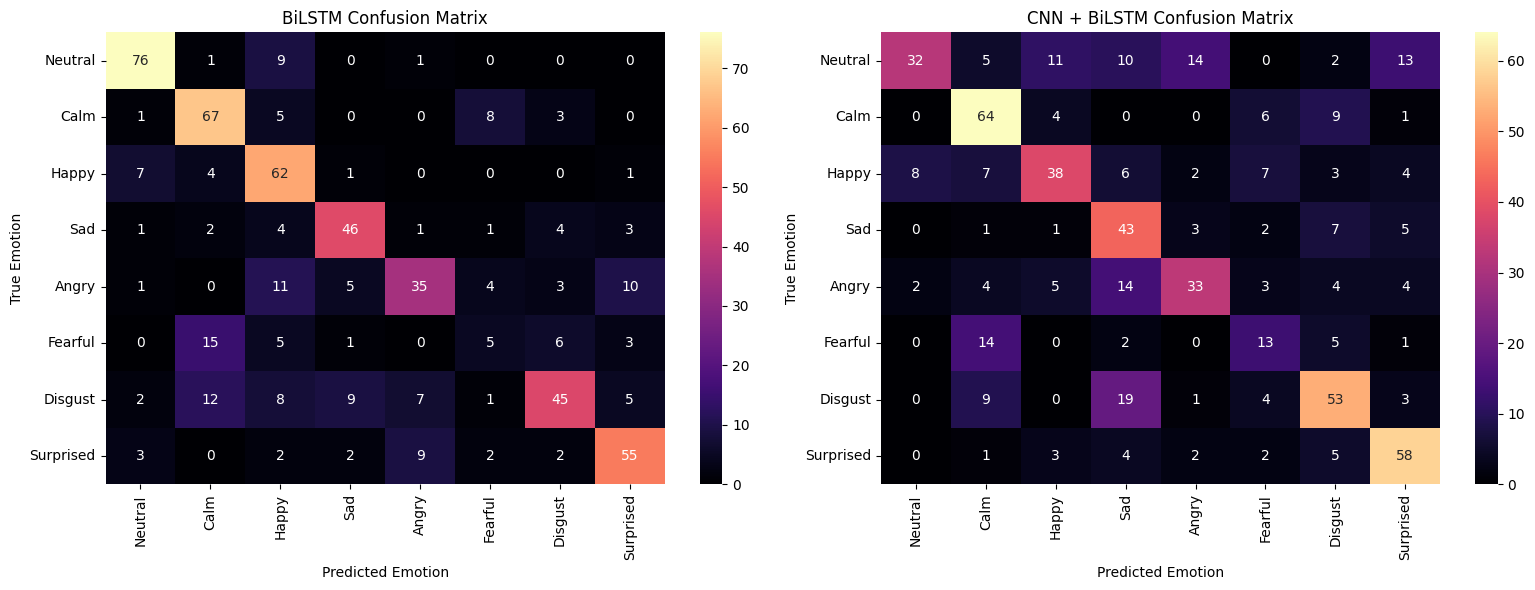

In [32]:
plt.figure(figsize=(16,6))

# BiLSTM Heatmap
plt.subplot(1,2,1)

sns.heatmap(cm_bi,
            annot=True,
            fmt="d",
            cmap="magma",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")


# CNN + BiLSTM Heatmap
plt.subplot(1,2,2)

sns.heatmap(cm_cnn,
            annot=True,
            fmt="d",
            cmap="magma",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("CNN + BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")

plt.tight_layout()
plt.show()